## Evaluation Baseline Models: 
Evaluate three-way baseline model provided by sustain-lc:
1. Rule-based controls. PID controls for CDU built into FMU if .env() is not called. CT always follows the wetbulb temp unless RL sets an offset on top of it. So set point never exceeds the max range of cooling physically possible. (Wetbulb determines min temperature reached).
2. Multi-Agent PPO & Multihead PPO. Run multiagent_ca_ppo.py built on ca_ppo.py combined with the multiagent_ppo files. Run multihead_ca_ppo.py built on ca_ppo.py combined with multihead_ppo files.
    2.1: Multi-Agent PPO.
    2.2: Multi-Head PPO.
3. MLP Baseline
4. Simple Graph-Based Approaches. Variations of GAT, GINE, MESHGRAPHNET.

Run three control models in the same episode within the FMU, compare and plot results.

### 0. Environment Initialization

In [ ]:
# general dependencies
import os
from datetime import datetime
import tqdm
import torch
import pyfmi
import numpy as np
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt
import copy as cp
from pathlib import path
from gymnasium import spaces
from scipy.special import softmax
from frontier_env import SmallFrontierModel

In [ ]:
# evaluation environment vars
env_name = "SmallFrontierModel"
reward_shaping_version = 'reward_shaping_v2'
exogen_var_version = 2

sfm = SmallFrontierModel(use_reward_shaping = f'reward_shaping_v{reward_shaping_version}', exogen_gen_v = f'{exogen_var_version}')
episode_length = np.arange(0, 24*60*60+1, 15) #a day (24 hrs split into 15s steps)

### 1. Rule-based PID Control (No agents/RL Strategy)

In [ ]:
# Rule-Based (PID) Model Benchmark
# creating list of dicts, and rule-based action
rule_rec = []
rule_based_action = {
            'cdu-cabinet-1': np.array([-0.2, -0.615, 1/3, 1/3, 1/3]),
            'cdu-cabinet-2': np.array([-0.2, -0.615, 1/3, 1/3, 1/3]),
            'cdu-cabinet-3': np.array([-0.2, -0.615, 1/3, 1/3, 1/3]),
            'cdu-cabinet-4': np.array([-0.2, -0.615, 1/3, 1/3, 1/3]),
            'cdu-cabinet-5': np.array([-0.2, -0.615, 1/3, 1/3, 1/3]),
            'cooling-tower-1': 4
        }

# reset FMU model env before running an ep
sfm.reset()

# creates a list of dictionaries with each dict being a single timestep entry, values are scaled
for k in episode_length:
    state, reward, done, info = sfm.step(rule_based_action)
    temp_dict = {"timestep": k/15,
                 "reward": reward,
                 # Server-side Coolant Supply Temp
                 "block-1_boundary-1.T": info['cdu-cabinet-1'][0],
                 "block-1_boundary-2.T": info['cdu-cabinet-1'][1],
                 "block-1_boundary-3.T": info['cdu-cabinet-1'][2],
                 "block-2_boundary-1.T": info['cdu-cabinet-2'][0],
                 "block-2_boundary-2.T": info['cdu-cabinet-2'][1],
                 "block-2_boundary-3.T": info['cdu-cabinet-2'][2],
                 "block-3_boundary-1.T": info['cdu-cabinet-3'][0],
                 "block-3_boundary-2.T": info['cdu-cabinet-3'][1],
                 "block-3_boundary-3.T": info['cdu-cabinet-3'][2],
                 "block-4_boundary-1.T": info['cdu-cabinet-4'][0],
                 "block-4_boundary-2.T": info['cdu-cabinet-4'][1],
                 "block-4_boundary-3.T": info['cdu-cabinet-4'][2],
                 "block-5_boundary-1.T": info['cdu-cabinet-5'][0],
                 "block-5_boundary-2.T": info['cdu-cabinet-5'][1],
                 "block-5_boundary-3.T": info['cdu-cabinet-5'][2],

                 # Cooling Tower Data
                 "CT-cell1.PFan": info['cooling-tower-1'][0],
                 "CT-cell2.PFan": info['cooling-tower-1'][1],
                 }
    
    temp_dict['total fan power'] = temp_dict['CT-cell1.PFan'] + temp_dict['CT-cell2.PFan']

    rule_rec.append(temp_dict)

FMU file loaded correctly: c:\Users\frank\NVAITC_files\NVAITC\sustain-lc/LC_Frontier_5Cabinet_4_17_25.fmu


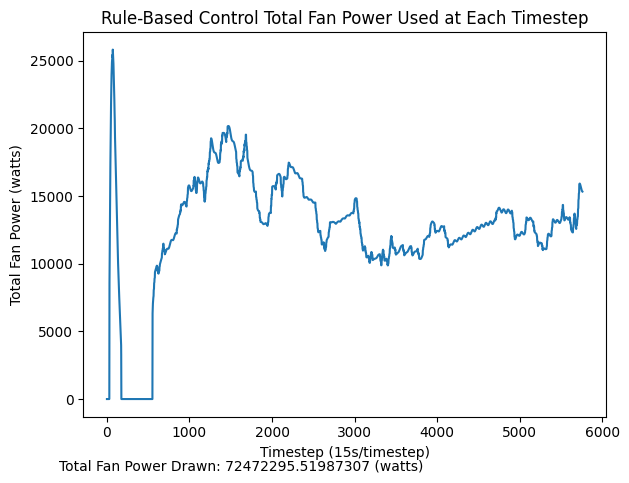

In [ ]:
# Plotting
# conversion to unscaled physical values for plotting & evaluation
rule_df = pd.DataFrame(rule_rec)
   
# sum of total power drawn by 2 CT cell fans across all time steps
sum_power = rule_df['total fan power'].sum()

plt.figure()
# testing out lambda, but will need to restructure list of dicts above later
plt.plot(rule_df['timestep'], rule_df['total fan power'])
plt.title("Rule-Based Control Total Fan Power Used at Each Timestep")
plt.xlabel("Timestep (15s/timestep)")
plt.ylabel("Total Fan Power (watts)")
plt.figtext(0.1, 0.01, f"Total Fan Power Drawn: {sum_power} (watts)")
plt.tight_layout()
plt.show()

### 2.1 Multi-Agent PPO

In [ ]:
# MA PPO Dependencies
from multiagent_ca_ppo import multiagent_ppo_dtde
from train_multiagent_ca_ppo import batchify_observations, categorize_actions

In [ ]:
# MA PPO specific vars
random_seed = 123
run_num_pretrained = 3
MA_weights_directory = path("MA_CA_PPO_preTrained\SmallFrontierModel")

In [ ]:
# set seed for reproducibility
if random_seed:       
    torch.manual_seed(random_seed)
    sfm.seed(random_seed)  # pylint: disable=no-member
    np.random.seed(random_seed)

# init agents and load trained weights,
agent_mdp_dict = {'CDUCAB' : {'state_dim': sfm.observation_space['cdu-cabinet-1'].shape[0], 'action_dim': env.action_space['cdu-cabinet-1'].shape[0], 
                                    'num_centralized_actions' : 5, 'has_continuous_action_space': True},
                      
                  'CT'     : {'state_dim': sfm.observation_space['cooling-tower-1'].shape[0], 'action_dim': env.action_space['cooling-tower-1'].n, 
                                    'num_centralized_actions' : 1, 'has_continuous_action_space': False}
                }

ppo_agent = multiagent_ppo_dtde(agent_mdp_dict)

# agent id identifies whether the agent determines server/rack controls or CT controls
for agent_id in agent_mdp_dict.keys():
    checkpoint_path = MA_weights_directory + "PPO_{}_{}_{}_agent_{}.pth".format(env_name, random_seed, run_num_pretrained, agent_id)
    assert os.path.exists(checkpoint_path), f"Error: {checkpoint_path} does not exist"
    ppo_agent.load(checkpoint_path, agent_id)

In [ ]:
# MA PPO Benchmark
MA_PPO_rec = []

# reset FMU model env before running an ep
state = sfm.reset()
batch_state_dict = batchify_observations(state)

# different from rule based, RL agents chooses most optimal actions
# for both CDU & Server Rack and CT controlls. Action dict is created to
# store such chosen optimal actions, and is then fed into the FMU
# to take the next step.

# categorize & batchify is to transform between data structures the step
# function takes in (an action dict via categorize), and batchify turns dict
# into an array that the RL agents can read.

# still a list of dicts is kept as the result for df conversion & plotting
for k in episode_length:
    
    actions = {}  # list to store actions for each agent

    # select action for CDU setups
    action = ppo_agent.select_action(batch_state_dict['CDUCAB'], 'CDUCAB')
    actions['CDUCAB'] = action
    # select action for cooling tower
    action = ppo_agent.select_action(batch_state_dict['CT'], 'CT')
    actions['CT'] = action

    # categorize actions in to dict format for env
    categorized_actions = categorize_actions(actions)

    state, rewards, done, info = sfm.step(categorized_actions)
    batch_state_dict = batchify_observations(state)

    temp_dict = {"timestep": k/15,
                 "reward": reward,
                 # Server-side Coolant Supply Temp
                 "block-1_boundary-1.T": info['cdu-cabinet-1'][0],
                 "block-1_boundary-2.T": info['cdu-cabinet-1'][1],
                 "block-1_boundary-3.T": info['cdu-cabinet-1'][2],
                 "block-2_boundary-1.T": info['cdu-cabinet-2'][0],
                 "block-2_boundary-2.T": info['cdu-cabinet-2'][1],
                 "block-2_boundary-3.T": info['cdu-cabinet-2'][2],
                 "block-3_boundary-1.T": info['cdu-cabinet-3'][0],
                 "block-3_boundary-2.T": info['cdu-cabinet-3'][1],
                 "block-3_boundary-3.T": info['cdu-cabinet-3'][2],
                 "block-4_boundary-1.T": info['cdu-cabinet-4'][0],
                 "block-4_boundary-2.T": info['cdu-cabinet-4'][1],
                 "block-4_boundary-3.T": info['cdu-cabinet-4'][2],
                 "block-5_boundary-1.T": info['cdu-cabinet-5'][0],
                 "block-5_boundary-2.T": info['cdu-cabinet-5'][1],
                 "block-5_boundary-3.T": info['cdu-cabinet-5'][2],

                 # Cooling Tower Data
                 "CT-cell1.PFan": info['cooling-tower-1'][0],
                 "CT-cell2.PFan": info['cooling-tower-1'][1],
                 }
    
    temp_dict['total fan power'] = temp_dict['CT-cell1.PFan'] + temp_dict['CT-cell2.PFan']

    MA_PPO_rec.append(temp_dict)

In [ ]:
# Plotting
# conversion to unscaled physical values for plotting & evaluation
MA_PPO_df = pd.DataFrame(MA_PPO_rec)
   
# sum of total power drawn by 2 CT cell fans across all time steps
sum_power = rule_df['total fan power'].sum()

plt.figure()
# testing out lambda, but will need to restructure list of dicts above later
plt.plot(MA_PPO_df['timestep'], MA_PPO_df['total fan power'])
plt.title("Rule-Based Control Total Fan Power Used at Each Timestep")
plt.xlabel("Timestep (15s/timestep)")
plt.ylabel("Total Fan Power (watts)")
plt.figtext(0.1, 0.01, f"Total Fan Power Drawn: {sum_power} (watts)")
plt.tight_layout()
plt.show()

### 2.2 Multi-Head PPO

In [ ]:
# MH PPO Dependencies
from multiagent_ca_ppo import multiagent_ppo_dtde
from mh_frontier_env import MH_SmallFrontierModel
from train_mh_ma_ca_ppo import batchify_observations, categorize_actions

In [ ]:
# MA PPO specific vars
random_seed = 123
env_name = "MH_SmallFrontierModel"
agent_type = 'MultiHead_CA_PPO'
run_num_pretrained = 2
MH_weights_directory = path("MH_MA_CA_PPO_preTrained\MH_SmallFrontierModel")

In [ ]:
# set seed for reproducibility
if random_seed:       
    torch.manual_seed(random_seed)
    sfm.seed(random_seed)  # pylint: disable=no-member
    np.random.seed(random_seed)

# init agents and load trained weights,
agent_mdp_dict = {'CDUCAB' : {'state_dim': sfm.observation_space['cdu-cabinet-1'].shape[0], 
                              'action_dim': {'top-level':sfm.action_space['cdu-cabinet-1']['top-level'].shape[0], 
                                             'valve-level':sfm.action_space['cdu-cabinet-1']['valve-level'].shape[0]}, 
                              'num_centralized_actions' : 5},
                      
                    'CT'        : {'state_dim': sfm.observation_space['cooling-tower-1'].shape[0],
                                   'action_dim': sfm.action_space['cooling-tower-1'].n, 
                                   'num_centralized_actions' : 1, 
                                   'has_continuous_action_space': False}
}

ppo_agent = multiagent_ppo_dtde(agent_mdp_dict, agent_type=agent_type)

for agent_id in agent_mdp_dict.keys():
    checkpoint_path = MH_weights_directory + "PPO_{}_{}_{}_agent_{}.pth".format(env_name, random_seed, run_num_pretrained, agent_id)
    assert os.path.exists(checkpoint_path), f"Error: {checkpoint_path} does not exist"
    ppo_agent.load(checkpoint_path, agent_id)

In [ ]:
# MA PPO Benchmark
MH_PPO_rec = []

# reset FMU model env before running an ep
state = sfm.reset()
batch_state_dict = batchify_observations(state)

# still a list of dicts is kept as the result for df conversion & plotting
for k in episode_length:
    
    actions = {'CDUCAB': {'top-level' : None, 'valve-level' : None}, 'CT' : None}  # list to store actions for each agent

    # select action for CDU setups
    action = ppo_agent.select_action(batch_state_dict['CDUCAB'], 'CDUCAB')
    actions['CDUCAB']['top-level'], actions['CDUCAB']['valve-level'] = action
    # select action for cooling tower
    action = ppo_agent.select_action(batch_state_dict['CT'], 'CT')
    actions['CT'] = action
            
    # categorize actions in to dict format for env
    categorized_actions = categorize_actions(actions)

    state, rewards, done, info = sfm.step(categorized_actions)
    batch_state_dict = batchify_observations(state)
   
    temp_dict = {"timestep": k/15,
                 "reward": reward,
                 # Server-side Coolant Supply Temp
                 "block-1_boundary-1.T": info['cdu-cabinet-1'][0],
                 "block-1_boundary-2.T": info['cdu-cabinet-1'][1],
                 "block-1_boundary-3.T": info['cdu-cabinet-1'][2],
                 "block-2_boundary-1.T": info['cdu-cabinet-2'][0],
                 "block-2_boundary-2.T": info['cdu-cabinet-2'][1],
                 "block-2_boundary-3.T": info['cdu-cabinet-2'][2],
                 "block-3_boundary-1.T": info['cdu-cabinet-3'][0],
                 "block-3_boundary-2.T": info['cdu-cabinet-3'][1],
                 "block-3_boundary-3.T": info['cdu-cabinet-3'][2],
                 "block-4_boundary-1.T": info['cdu-cabinet-4'][0],
                 "block-4_boundary-2.T": info['cdu-cabinet-4'][1],
                 "block-4_boundary-3.T": info['cdu-cabinet-4'][2],
                 "block-5_boundary-1.T": info['cdu-cabinet-5'][0],
                 "block-5_boundary-2.T": info['cdu-cabinet-5'][1],
                 "block-5_boundary-3.T": info['cdu-cabinet-5'][2],

                 # Cooling Tower Data
                 "CT-cell1.PFan": info['cooling-tower-1'][0],
                 "CT-cell2.PFan": info['cooling-tower-1'][1],
                 }
    
    temp_dict['total fan power'] = temp_dict['CT-cell1.PFan'] + temp_dict['CT-cell2.PFan']

    MH_PPO_rec.append(temp_dict)

In [ ]:
# Plotting
# conversion to unscaled physical values for plotting & evaluation
MA_PPO_df = pd.DataFrame(MA_PPO_rec)
   
# sum of total power drawn by 2 CT cell fans across all time steps
sum_power = rule_df['total fan power'].sum()

plt.figure()
# testing out lambda, but will need to restructure list of dicts above later
plt.plot(MA_PPO_df['timestep'], MA_PPO_df['total fan power'])
plt.title("Rule-Based Control Total Fan Power Used at Each Timestep")
plt.xlabel("Timestep (15s/timestep)")
plt.ylabel("Total Fan Power (watts)")
plt.figtext(0.1, 0.01, f"Total Fan Power Drawn: {sum_power} (watts)")
plt.tight_layout()
plt.show()